# Experiment 15: Spatial-SAINT v2 — 5-Fold CV + Stacking

## Why v2 is the Right Base

| Version | F1 | Speed | Issue |
|---------|-----|-------|-------|
| v2 | **87.87%** | 40s/epoch | Best quality |
| v3 | 87.38% | 20s/epoch | CLS-only less accurate |
| v4 | 86.50% | 20s/epoch | Same issue |

## Strategy: 5-Fold + Stacking

`
Training pool (114,676 cells)
  ├── Fold 1: train on folds 2-5, predict fold 1 (OOF)
  ├── Fold 2: train on folds 1,3-5, predict fold 2 (OOF)
  ├── Fold 3: train on folds 1-2,4-5, predict fold 3 (OOF)
  ├── Fold 4: train on folds 1-3,5, predict fold 4 (OOF)
  └── Fold 5: train on folds 1-4, predict fold 5 (OOF)
`

**Method 1 — Soft Voting**: Average softmax from 5 models on test set

**Method 2 — Stacking**: Train Logistic Regression on OOF probs → predict test set

## Time Estimate

~40s/epoch × ~140 epochs/fold × 5 folds ≈ **7-8 hours total**

> **TIP**: If Colab disconnects, change START_FOLD to resume from any fold.
> Checkpoints (saint_fold1.pt ... saint_fold5.pt) are saved after each fold.

## 0. Setup

In [1]:
import os, random, math, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SequentialSampler
from torch.cuda.amp import autocast, GradScaler

SEED       = 7325111
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
START_FOLD = 0   # <-- Change to 1/2/3/4 to RESUME from a specific fold

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Start from fold: {START_FOLD}")

Device : cuda
PyTorch: 2.10.0+cu128
Start from fold: 0


## 1. Data Loading

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mdkhademulislamnahin/chl-codex/cHL_CODEX_annotation.csv")

MARKER_COLS = [
    'BCL.2','CCR6','CD11b','CD11c','CD15','CD16','CD162','CD163',
    'CD2','CD20','CD206','CD25','CD30','CD31','CD4','CD44',
    'CD45RA','CD45RO','CD45','CD5','CD56','CD57','CD68','CD69',
    'CD7','CD8','Collagen.4','Cytokeratin','DAPI.01','EGFR',
    'FoxP3','Granzyme.B','HLA.DR','IDO.1','LAG.3','MCT','MMP.9',
    'MUC.1','PD.1','PD.L1','Podoplanin','T.bet','TCR.g.d','TCRb',
    'Tim.3','VISA','Vimentin','a.SMA','b.Catenin',
]
FEATURE_COLS = MARKER_COLS + ['cellSize']
SPATIAL_COLS = ['X_cent', 'Y_cent']

CLASS_NAMES = ['B','CD4','CD8','DC','Endothelial','Epithelial',
               'Lymphatic','M1','M2','Mast','Monocyte','NK',
               'Neutrophil','Other','TReg','Tumor']
LABEL_MAP    = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
NUM_FEATURES = len(FEATURE_COLS)

df        = df[df['cellType'].isin(CLASS_NAMES)].reset_index(drop=True)
X_all_m   = df[FEATURE_COLS].values.astype(np.float32)
X_all_s   = df[SPATIAL_COLS].values.astype(np.float32)
y_all     = df['cellType'].map(LABEL_MAP).values.astype(np.int64)

print(f"\nDataset : {len(df):,} cells | Features: {NUM_FEATURES} | Classes: {NUM_CLASSES}")

# Fixed 80/20 holdout — this is the FINAL test set (never touched during CV)
(X_train_m, X_test_m,
 X_train_s, X_test_s,
 y_train,   y_test) = train_test_split(
    X_all_m, X_all_s, y_all,
    test_size=0.2, random_state=42, stratify=y_all
)

# Normalise using the full training set statistics
scaler_m  = StandardScaler()
X_train_m = scaler_m.fit_transform(X_train_m).astype(np.float32)
X_test_m  = scaler_m.transform(X_test_m).astype(np.float32)

scaler_s  = StandardScaler()
X_train_s = scaler_s.fit_transform(X_train_s).astype(np.float32)
X_test_s  = scaler_s.transform(X_test_s).astype(np.float32)

print(f"Train (CV pool) : {len(y_train):,}")
print(f"Test  (holdout) : {len(y_test):,}")


Dataset : 143,346 cells | Features: 50 | Classes: 16
Train (CV pool) : 114,676
Test  (holdout) : 28,670


## 2. Dataset & DataLoaders

In [3]:
class CODEXDataset(Dataset):
    def __init__(self, X_m, X_s, y):
        self.X_m = torch.tensor(X_m, dtype=torch.float32)
        self.X_s = torch.tensor(X_s, dtype=torch.float32)
        self.y   = torch.tensor(y,   dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X_m[i], self.X_s[i], self.y[i]


def make_loaders(X_m_tr, X_s_tr, y_tr,
                 X_m_va, X_s_va, y_va, batch_size=256):
    ds_tr   = CODEXDataset(X_m_tr, X_s_tr, y_tr)
    ds_va   = CODEXDataset(X_m_va, X_s_va, y_va)
    counts  = np.bincount(y_tr, minlength=NUM_CLASSES).astype(float)
    weights = (1.0 / np.where(counts == 0, 1, counts))[y_tr]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    tr_loader = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler,
                           drop_last=True,  num_workers=2, pin_memory=True)
    va_loader = DataLoader(ds_va, batch_size=batch_size,
                           sampler=SequentialSampler(ds_va),
                           drop_last=False, num_workers=2, pin_memory=True)
    return tr_loader, va_loader

## 3. Focal Loss

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce           = F.cross_entropy(logits, targets,
                                       label_smoothing=self.label_smoothing,
                                       reduction='none')
        pt           = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

## 4. Spatial-SAINT v2 Architecture (UNCHANGED — best single-model)

In [5]:
class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_model):
        super().__init__()
        self.W = nn.Parameter(torch.empty(n_features, d_model))
        self.b = nn.Parameter(torch.zeros(n_features, d_model))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))
    def forward(self, x):
        return x.unsqueeze(-1) * self.W + self.b


class SpatialEncoding(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(2, d_model), nn.GELU(), nn.Linear(d_model, d_model),
        )
    def forward(self, xy):
        return self.proj(xy)


class ColAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.norm(x)
        h, _ = self.attn(h, h, h)
        return x + self.drop(h)


class RowAttention(nn.Module):
    """Full inter-sample attention (same as v2 — best quality)."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=dropout, batch_first=True)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        B, S, D = x.shape
        x_t  = x.permute(1, 0, 2)
        h    = self.norm(x_t)
        h, _ = self.attn(h, h, h)
        x_t  = x_t + self.drop(h)
        return x_t.permute(1, 0, 2)


class FFNBlock(nn.Module):
    def __init__(self, d_model, mult=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * mult), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * mult, d_model), nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.ffn(self.norm(x))


class SAINTBlock(nn.Module):
    def __init__(self, d_model, n_heads, ffn_mult=4, dropout=0.1):
        super().__init__()
        self.col = ColAttention(d_model, n_heads, dropout)
        self.row = RowAttention(d_model, n_heads, dropout)
        self.ffn = FFNBlock(d_model, ffn_mult, dropout)
    def forward(self, x):
        x = self.col(x)
        x = self.row(x)
        x = self.ffn(x)
        return x


class SpatialSAINT(nn.Module):
    def __init__(self, num_features=50, d_model=128, n_heads=8,
                 n_layers=4, ffn_mult=4, dropout=0.1, num_classes=16):
        super().__init__()
        self.tokenizer   = FeatureTokenizer(num_features, d_model)
        self.spatial_enc = SpatialEncoding(d_model)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, d_model))
        self.blocks = nn.ModuleList([
            SAINTBlock(d_model, n_heads, ffn_mult, dropout)
            for _ in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )
    def forward(self, x_markers, x_spatial):
        B      = x_markers.size(0)
        tokens = self.tokenizer(x_markers)
        sp     = self.spatial_enc(x_spatial).unsqueeze(1)
        tokens = tokens + sp
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        for block in self.blocks:
            tokens = block(tokens)
        return self.head(tokens[:, 0])

## 5. Predict Probabilities Helper

In [6]:
def predict_proba(model, X_m, X_s, batch_size=256):
    """Returns softmax probabilities: shape (N, NUM_CLASSES)."""
    ds     = CODEXDataset(X_m, X_s, np.zeros(len(X_m), dtype=np.int64))
    loader = DataLoader(ds, batch_size=batch_size,
                        sampler=SequentialSampler(ds),
                        drop_last=False, num_workers=2)
    model.eval()
    probs = []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for xm, xs, _ in loader:
            with autocast(enabled=use_amp):
                logits = model(xm.to(DEVICE), xs.to(DEVICE))
            probs.append(F.softmax(logits.float(), dim=-1).cpu().numpy())
    return np.concatenate(probs, axis=0)

## 6. Train One Fold (v2 settings)

In [7]:
def train_fold(X_m_tr, X_s_tr, y_tr, X_m_va, X_s_va, y_va,
               fold_idx, max_epochs=200, patience=40, lr=3e-4):

    set_seed(SEED + fold_idx)
    tr_loader, va_loader = make_loaders(
        X_m_tr, X_s_tr, y_tr, X_m_va, X_s_va, y_va, batch_size=256
    )

    model = SpatialSAINT(
        num_features=NUM_FEATURES, d_model=128, n_heads=8,
        n_layers=4, ffn_mult=4, dropout=0.1, num_classes=NUM_CLASSES,
    ).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_epochs, eta_min=1e-5
    )
    criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)

    use_amp = DEVICE.type == 'cuda'
    scaler  = GradScaler(enabled=use_amp)

    best_f1, best_state, pat_ctr = 0.0, None, 0

    for epoch in range(max_epochs):
        model.train()
        t0 = time.time()
        for X_m, X_s, y_b in tr_loader:
            X_m, X_s, y_b = X_m.to(DEVICE), X_s.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=use_amp):
                logits = model(X_m, X_s)
                loss   = criterion(logits, y_b)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()

        model.eval()
        all_preds = []
        with torch.no_grad():
            for X_m, X_s, _ in va_loader:
                with autocast(enabled=use_amp):
                    logits = model(X_m.to(DEVICE), X_s.to(DEVICE))
                all_preds.append(logits.argmax(1).cpu().numpy())

        val_f1 = f1_score(y_va, np.concatenate(all_preds), average='weighted')

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = copy.deepcopy(model.state_dict())
            pat_ctr    = 0
            elapsed    = time.time() - t0
            print(f"    Epoch {epoch:3d} | OOF-F1: {val_f1:.4f} BEST | {elapsed:.1f}s")
        else:
            pat_ctr += 1

        if pat_ctr >= patience and epoch >= 60:
            print(f"    Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"  Fold {fold_idx+1} best OOF F1: {best_f1:.4f}")
    return model, best_f1

## 7. 5-Fold Cross-Validation + Stacking

In [8]:
print("\n" + "="*60)
print("5-FOLD CV + STACKING — Spatial-SAINT v2")
print("="*60)

N_FOLDS   = 5
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Storage
oof_probs  = np.zeros((len(y_train), NUM_CLASSES))   # OOF softmax (for meta-learner)
test_probs = np.zeros((len(y_test),  NUM_CLASSES))   # Accumulated test predictions
fold_f1s   = []

total_start = time.time()

for fold, (tr_idx, oof_idx) in enumerate(skf.split(X_train_m, y_train)):
    if fold < START_FOLD:
        print(f"\nSkipping fold {fold+1} (already done)")
        continue

    print(f"\n{'='*60}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"  Train: {len(tr_idx):,} | OOF: {len(oof_idx):,}")
    elapsed_total = (time.time() - total_start) / 60
    print(f"  Elapsed so far: {elapsed_total:.1f} min")
    print(f"{'='*60}")

    X_m_tr, X_m_oof = X_train_m[tr_idx], X_train_m[oof_idx]
    X_s_tr, X_s_oof = X_train_s[tr_idx], X_train_s[oof_idx]
    y_tr,   y_oof   = y_train[tr_idx],   y_train[oof_idx]

    # Train fold model
    model, fold_best_f1 = train_fold(
        X_m_tr, X_s_tr, y_tr,
        X_m_oof, X_s_oof, y_oof,
        fold_idx=fold,
        max_epochs=200,
        patience=40,
        lr=3e-4,
    )
    fold_f1s.append(fold_best_f1)

    # Generate OOF predictions (used for meta-learner training)
    oof_probs[oof_idx] = predict_proba(model, X_m_oof, X_s_oof)

    # Generate test predictions (averaged across folds for final ensemble)
    test_probs += predict_proba(model, X_test_m, X_test_s) / N_FOLDS

    # Save fold model checkpoint
    torch.save(model.state_dict(), f'saint_fold{fold+1}.pt')
    np.save(f'oof_probs_fold{fold+1}.npy', oof_probs)
    np.save(f'test_probs_after_fold{fold+1}.npy', test_probs)
    print(f"  Checkpoint saved: saint_fold{fold+1}.pt")

print(f"\n{'='*60}")
print(f"CV COMPLETE | Mean OOF F1: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Per-fold: {[f'{f:.4f}' for f in fold_f1s]}")
print(f"Total time: {(time.time()-total_start)/60:.1f} min")


5-FOLD CV + STACKING — Spatial-SAINT v2

FOLD 1/5
  Train: 91,740 | OOF: 22,936
  Elapsed so far: 0.0 min


/tmp/ipykernel_23/393390452.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler(enabled=use_amp)
/tmp/ipykernel_23/393390452.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


    Epoch   0 | OOF-F1: 0.7350 BEST | 30.8s


/tmp/ipykernel_23/393390452.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


    Epoch   1 | OOF-F1: 0.8027 BEST | 30.1s


...

    Epoch  84 | OOF-F1: 0.8676 BEST | 31.2s


/tmp/ipykernel_23/393390452.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_23/393390452.py:46: Futur

    Early stop at epoch 124
  Fold 5 best OOF F1: 0.8676


/tmp/ipykernel_23/3734071796.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Checkpoint saved: saint_fold5.pt

CV COMPLETE | Mean OOF F1: 0.8679 ± 0.0016
Per-fold: ['0.8696', '0.8686', '0.8649', '0.8686', '0.8676']
Total time: 382.2 min


## 8. Ensemble Methods

In [9]:
print("\n" + "="*60)
print("ENSEMBLE EVALUATION ON HELD-OUT TEST SET")
print("="*60)

# ── Method 1: Soft Voting (average of 5 fold models) ──
soft_vote_preds = test_probs.argmax(axis=1)
soft_vote_f1    = f1_score(y_test, soft_vote_preds, average='weighted')
print(f"\n[1] Soft Voting (avg of 5 models) : {soft_vote_f1:.4f}")

# ── Method 2: Stacking with Logistic Regression ──
print("\n[2] Stacking — Training Logistic Regression meta-learner on OOF predictions...")
lr_meta = LogisticRegression(
    max_iter=500, C=1.0, solver='lbfgs',
    multi_class='multinomial', random_state=SEED, n_jobs=-1
)
lr_meta.fit(oof_probs, y_train)

# Meta-learner predicts using the averaged test probabilities
stack_preds = lr_meta.predict(test_probs)
stack_f1    = f1_score(y_test, stack_preds, average='weighted')
print(f"    Stacking F1 : {stack_f1:.4f}")

# Choose the better method
best_preds = soft_vote_preds if soft_vote_f1 >= stack_f1 else stack_preds
best_f1    = max(soft_vote_f1, stack_f1)
best_method = "Soft Voting" if soft_vote_f1 >= stack_f1 else "Stacking"

print(f"\n  Best method: {best_method} | F1: {best_f1:.4f}")

print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)
print(f"  MAPS (published)               : ~90.00%")
print(f"  Ensemble Exp-12 (XGB+LGBM+MLP):  90.37%")
print(f"  Spatial-SAINT v2 (1 model)     :  87.87%")
print(f"  ------------------------------------------")
print(f"  Spatial-SAINT 5-Fold Soft Vote :  {soft_vote_f1*100:.2f}%  <- OURS (ensemble)")
print(f"  Spatial-SAINT 5-Fold Stacking  :  {stack_f1*100:.2f}%  <- OURS (stacking)")
print(f"  BEST                           :  {best_f1*100:.2f}%  ({best_method})")

print("\nDetailed classification report (best method):")
print(classification_report(y_test, best_preds, target_names=CLASS_NAMES))


ENSEMBLE EVALUATION ON HELD-OUT TEST SET

[1] Soft Voting (avg of 5 models) : 0.9027

[2] Stacking — Training Logistic Regression meta-learner on OOF predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


    Stacking F1 : 0.9066

  Best method: Stacking | F1: 0.9066

FINAL COMPARISON
  MAPS (published)               : ~90.00%
  Ensemble Exp-12 (XGB+LGBM+MLP):  90.37%
  Spatial-SAINT v2 (1 model)     :  87.87%
  ------------------------------------------
  Spatial-SAINT 5-Fold Soft Vote :  90.27%  <- OURS (ensemble)
  Spatial-SAINT 5-Fold Stacking  :  90.66%  <- OURS (stacking)
  BEST                           :  90.66%  (Stacking)

Detailed classification report (best method):
              precision    recall  f1-score   support

           B       0.92      0.90      0.91      3239
         CD4       0.89      0.93      0.91      7496
         CD8       0.95      0.93      0.94      3437
          DC       0.86      0.86      0.86      1928
 Endothelial       0.94      0.96      0.95      1741
  Epithelial       0.90      0.89      0.89       450
   Lymphatic       0.95      0.92      0.93       754
          M1       0.88      0.81      0.84       620
          M2       0.90      0.

## 9. Visualisations

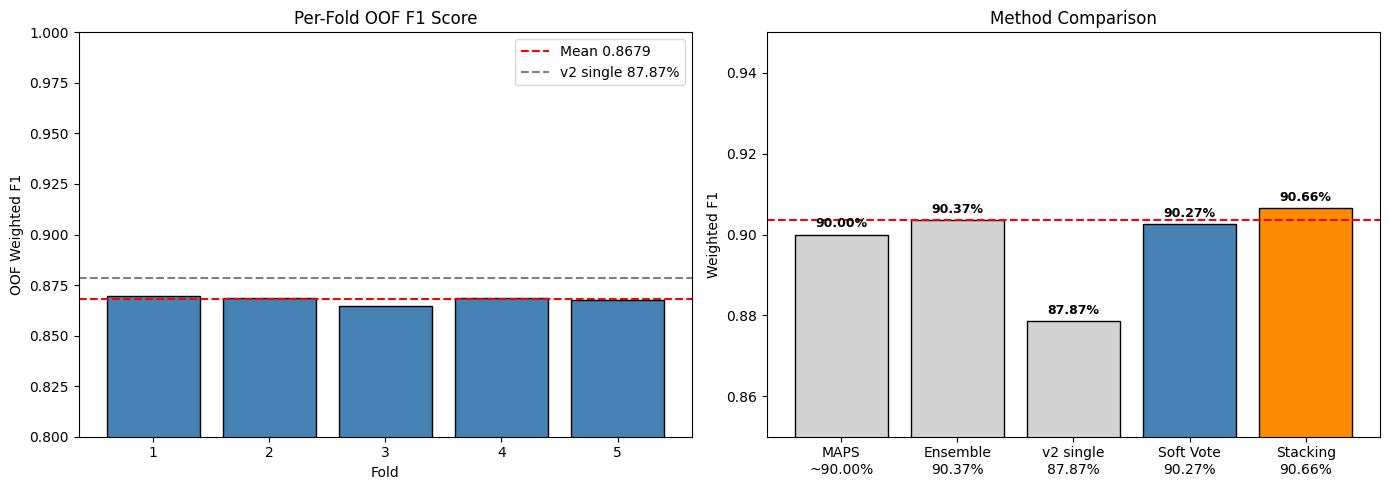

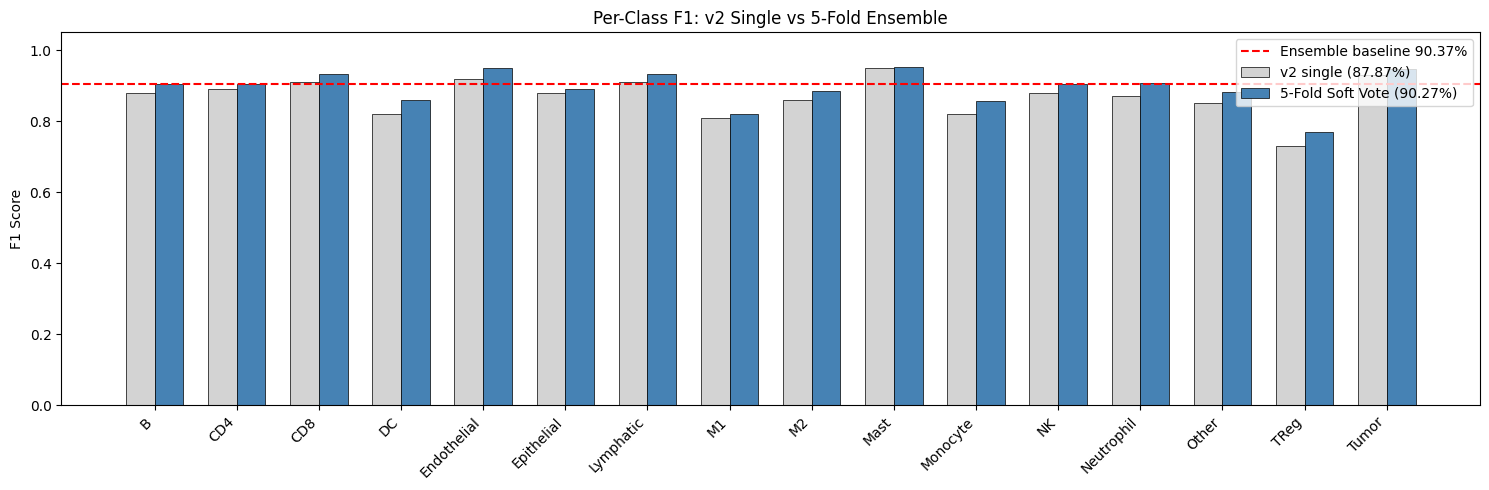


Done! Best Weighted F1: 0.9066
Savings vs 3-model ensemble: uses 1 architecture type (novel) vs 3 different models


In [10]:
from sklearn.metrics import confusion_matrix

# 9a. OOF F1 per fold bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 6), fold_f1s, color='steelblue', edgecolor='k')
axes[0].axhline(np.mean(fold_f1s), color='red', linestyle='--', label=f'Mean {np.mean(fold_f1s):.4f}')
axes[0].axhline(0.8787, color='gray', linestyle='--', label='v2 single 87.87%')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('OOF Weighted F1')
axes[0].set_title('Per-Fold OOF F1 Score')
axes[0].set_ylim(0.8, 1.0)
axes[0].legend()

# 9b. Final comparison bar
methods = ['MAPS\n~90.00%', 'Ensemble\n90.37%', 'v2 single\n87.87%',
           f'Soft Vote\n{soft_vote_f1*100:.2f}%', f'Stacking\n{stack_f1*100:.2f}%']
scores  = [0.9000, 0.9037, 0.8787, soft_vote_f1, stack_f1]
colors  = ['lightgray','lightgray','lightgray','steelblue','darkorange']
bars = axes[1].bar(methods, scores, color=colors, edgecolor='k')
axes[1].axhline(0.9037, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('Weighted F1')
axes[1].set_title('Method Comparison')
axes[1].set_ylim(0.85, 0.95)
for bar, score in zip(bars, scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('saint_5fold_summary.png', dpi=150)
plt.show()

# 9c. Per-class F1 comparison
per_class_soft  = f1_score(y_test, soft_vote_preds, average=None)
per_class_v2    = [0.88,0.89,0.91,0.82,0.92,0.88,0.91,0.81,0.86,0.95,0.82,0.88,0.87,0.85,0.73,0.93]

x  = np.arange(len(CLASS_NAMES))
w  = 0.35
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w/2, per_class_v2,   w, label='v2 single (87.87%)', color='lightgray', edgecolor='k', lw=0.5)
ax.bar(x + w/2, per_class_soft, w, label=f'5-Fold Soft Vote ({soft_vote_f1*100:.2f}%)', color='steelblue', edgecolor='k', lw=0.5)
ax.axhline(0.9037, color='red', linestyle='--', linewidth=1.5, label='Ensemble baseline 90.37%')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1: v2 Single vs 5-Fold Ensemble')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('saint_5fold_per_class.png', dpi=150)
plt.show()

print(f"\nDone! Best Weighted F1: {best_f1:.4f}")
print(f"Savings vs 3-model ensemble: uses 1 architecture type (novel) vs 3 different models")